In [30]:
import pandas as pd

file_path = "C:/Users/Wheez/Desktop/Microplasticdata/FTIR_PLASTIC_c8.csv"

df = pd.read_csv(file_path)

print(df.head())


          IDE Polymer Technic  Sample  BR  RST   Data(x)  Data(Y)  Data(x).1  \
0  PETFTIR001     PET    FTIR       1  32    8  399.1927  71.8845   401.1211   
1  PETFTIR002     PET    FTIR       2  32    8  399.1927  96.7876   401.1211   
2  PETFTIR003     PET    FTIR       3  32    8  399.1927  66.1325   401.1211   
3  PETFTIR004     PET    FTIR       4  32    8  399.1927  68.6363   401.1211   
4  PETFTIR005     PET    FTIR       5  32    8  399.1927  70.3734   401.1211   

   Data(Y).1  ...  Data(x).1864  Data(Y).1864  Data(x).1865  Data(Y).1865  \
0    72.7970  ...      3993.855       95.0697     3995.7834       95.0639   
1    96.9246  ...      3993.855       98.1241     3995.7834       98.1257   
2    67.1290  ...      3993.855       93.0200     3995.7834       93.0228   
3    69.5071  ...      3993.855       95.2411     3995.7834       95.2405   
4    71.4349  ...      3993.855       94.5011     3995.7834       94.5043   

   Data(x).1866  Data(Y).1866  Data(x).1867  Data(Y).186

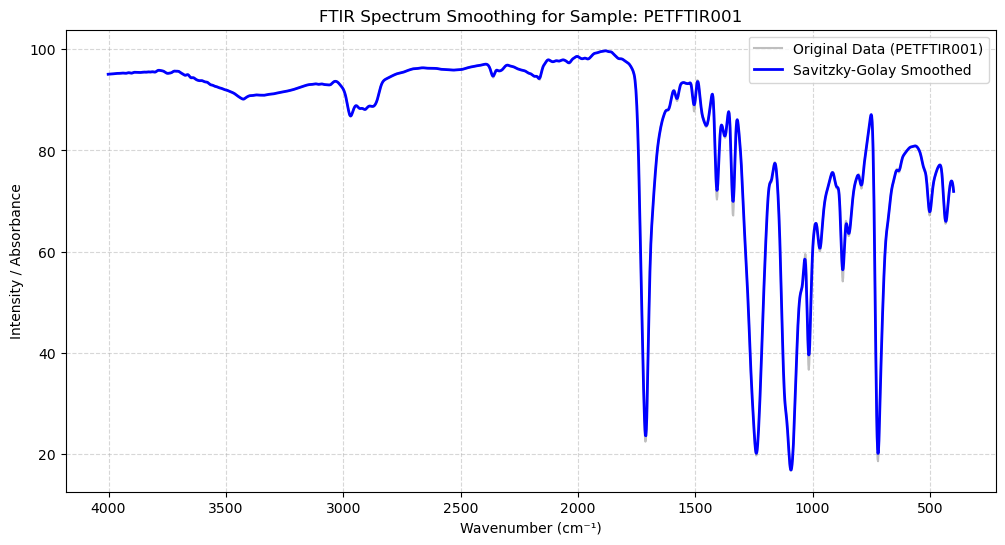

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 1. Load your microplastic data
file_path = "C:/Users/Wheez/Desktop/Microplasticdata/FTIR_PLASTIC_c8.csv"
df = pd.read_csv(file_path)

# 2. Select the specific sample row you want to analyze (0 = first row, 1 = second row, etc.)
row_index = 0
sample_name = df.loc[row_index, 'IDE']  # Gets the sample ID (e.g., PETFTIR001)

# 3. Dynamically collect all X (wavenumber) and Y (intensity) column values for this row
# This filters columns starting with 'Data(x)' or 'Data(Y)' and orders them properly
x_columns = [col for col in df.columns if col.startswith("Data(x)")]
y_columns = [col for col in df.columns if col.startswith("Data(Y)")]

x_values = df.loc[row_index, x_columns].astype(float).values
y_values = df.loc[row_index, y_columns].astype(float).values

# 4. Sort the data by X values to ensure a continuous spectrum for the filter
sort_idx = np.argsort(x_values)
x_sorted = x_values[sort_idx]
y_sorted = y_values[sort_idx]

# 5. Apply the Savitzky-Golay filter
# Adjust window_length (must be odd) and polyorder based on peak sharpness
y_smoothed = savgol_filter(y_sorted, window_length=15, polyorder=3)

# 6. Plot the original vs smoothed spectrum
plt.figure(figsize=(12, 6))
plt.plot(x_sorted, y_sorted, label=f"Original Data ({sample_name})", color="gray", alpha=0.5)
plt.plot(x_sorted, y_smoothed, label="Savitzky-Golay Smoothed", color="blue", lw=2)

# FTIR spectra traditionally have the wavenumber x-axis reversed
plt.gca().invert_xaxis()

plt.title(f"FTIR Spectrum Smoothing for Sample: {sample_name}")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Intensity / Absorbance")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
